# AutoTSForecast v0.5.0 — Agentic AI Tutorial

This tutorial walks you through every **agentic AI feature** in v0.5.0, step by step.

## What does "agentic" mean here?

Agentic features allow AI agents (GPT-4o, Claude, LangChain bots, etc.) to **call autotsforecast as a tool** — autonomously detecting anomalies, selecting the best forecast model, and explaining results in plain English, all without you writing custom glue code.

## What you will build

By the end of this tutorial you will have:

1. **Cleaned** your time-series data by automatically detecting and removing outliers
2. **Trained** an AutoForecaster that benchmarks 4 models and picks the best one
3. **Exported** the forecast as structured JSON — ready for any agent or API
4. **Summarised** the forecast in plain English using the InsightEngine
5. **Saved** the fitted model to a registry and reloaded it in a new session
6. **Wired** everything to OpenAI, Anthropic, LangChain, a REST API, and an MCP server

## Prerequisites

```bash
pip install "autotsforecast[agentic]"   # installs all extras
```

## How to run this notebook

Run the cells **top to bottom in order**. Each section builds on the previous one.  
Cells marked `# Optional` require an API key and can be skipped.


In [13]:
# Install the package with all agentic extras
# Uncomment the line below if running outside this repo
# !pip install "autotsforecast[agentic]" --quiet

# Or install from source (when inside the repo)
import subprocess, sys
subprocess.run([sys.executable, '-m', 'pip', 'install', '-e', '..', '--quiet'], check=True)
print('Installation complete.')

Installation complete.


In [14]:
import numpy as np
import pandas as pd
import warnings
warnings.filterwarnings('ignore')

np.random.seed(42)
print('NumPy:', np.__version__)
print('Pandas:', pd.__version__)

NumPy: 2.0.2
Pandas: 2.3.3


## Step 0 — Set Up Shared Data

Before using any agentic features we need a time-series dataset.  
In production you would load a CSV or database query here instead.

**What this cell does:**
- Creates 200 days of synthetic daily sales for two products (`product_a`, `product_b`)
- Adds trend, weekly seasonality, and random noise — realistic enough to test all features
- Deliberately **injects 4 spike outliers** so anomaly detection has something to find
- Splits into a training set (186 rows) and a 14-day hold-out test set

**Expected output:** a table showing the last 3 rows of training data.


In [15]:
n = 200
dates = pd.date_range('2023-01-01', periods=n, freq='D')

# Smooth signal + trend + seasonality
trend      = np.linspace(100, 160, n)
weekly     = 15 * np.sin(2 * np.pi * np.arange(n) / 7)
noise_a    = np.random.normal(0, 5, n)
noise_b    = np.random.normal(0, 8, n)

sales_a = trend + weekly + noise_a
sales_b = trend * 0.7 + weekly * 1.3 + noise_b

# Inject 4 outliers
for idx in [30, 80, 130, 175]:
    sales_a[idx] *= 3.5
    sales_b[idx + 2] *= 0.1

y = pd.DataFrame({'product_a': sales_a, 'product_b': sales_b}, index=dates)

HORIZON   = 14
y_train   = y.iloc[:-HORIZON]
y_test    = y.iloc[-HORIZON:]

print(f'Training: {len(y_train)} rows  |  Test: {len(y_test)} rows')
y_train.tail(3)

Training: 186 rows  |  Test: 14 rows


,product_a,product_b
2023-07-03,169.315714,119.662789
2023-07-04,168.983992,121.772204
2023-07-05,165.857153,118.709109


---

## Step 1 — Detect and Remove Anomalies

**Why do this before forecasting?**  
Outliers (spikes, missing data, sensor errors) distort model training. Cleaning them first
leads to more accurate forecasts without any manual inspection.

**How `AnomalyDetector` works:**

| Method | When to use |
|--------|-------------|
| `zscore` | Data is roughly normally distributed — good default |
| `iqr` | Heavy-tailed distributions, more robust than z-score |
| `isolation_forest` | High-dimensional or complex patterns (requires sklearn) |
| `forecast_residual` | Use residuals of a simple moving-average as the signal |

**Step-by-step:**
1. Instantiate `AnomalyDetector(method=..., threshold=...)` — higher threshold = fewer detections
2. Call `fit_predict(y_train)` → returns a boolean DataFrame (True = outlier)
3. Call `get_summary()` → returns a Pydantic object with counts per series — perfect for agents
4. Replace outlier rows with `NaN`, then interpolate to fill gaps cleanly
5. The chart shows red dots at every detected anomaly — confirm they match your injected spikes

**Expected output:**
- A boolean mask table listing which dates are anomalies
- Summary: method, total count, per-series count
- A chart with red dots at the spike positions


In [16]:
from autotsforecast.anomaly.detector import AnomalyDetector

# Z-score method
detector = AnomalyDetector(method='zscore', contamination=0.05, threshold=2.5)
anomalies = detector.fit_predict(y_train)

print('Anomaly mask (True = outlier):')
print(anomalies[anomalies.any(axis=1)])

Anomaly mask (True = outlier):
            product_a  product_b
2023-01-31       True      False
2023-02-02      False       True
2023-03-22       True      False
2023-03-24      False       True
2023-05-11       True      False
2023-05-13      False       True
2023-06-25       True      False
2023-06-27      False       True


In [17]:
# Get Pydantic summary
summary = detector.get_summary()
print(f'Method:           {summary.method}')
print(f'Total anomalies:  {sum(summary.n_anomalies.values())}')
print(f'Per series:       {summary.n_anomalies}')
print(f'Contamination:    {summary.contamination}')


Method:           zscore
Total anomalies:  8
Per series:       {'product_a': 4, 'product_b': 4}
Contamination:    0.05


**What you see above:** `n_anomalies` is a dict keyed by series name — an agent can read this directly without any parsing. `contamination=0.05` means "expect at most 5% of points to be outliers" — adjust this if you're getting too many or too few detections.

Now compare with the IQR method:


In [18]:
# IQR method
detector_iqr = AnomalyDetector(method='iqr', threshold=2.0)
anomalies_iqr = detector_iqr.fit_predict(y_train)
print(f'IQR anomalies: {anomalies_iqr.sum().to_dict()}')

IQR anomalies: {'product_a': 4, 'product_b': 4}


In [19]:
# Remove anomalies before forecasting
y_clean = y_train.copy()
y_clean[anomalies] = np.nan
y_clean = y_clean.interpolate(method='time')

removed = anomalies.sum().sum()
print(f'Removed {removed} anomaly rows; data now clean for forecasting.')
y_clean.tail(3)

Removed 8 anomaly rows; data now clean for forecasting.


,product_a,product_b
2023-07-03,169.315714,119.662789
2023-07-04,168.983992,121.772204
2023-07-05,165.857153,118.709109


**What just happened:** anomaly rows were set to `NaN` then filled using time-based linear interpolation. The resulting `y_clean` is ready for model training. The chart below confirms the anomalies (red dots) are exactly where we injected them.


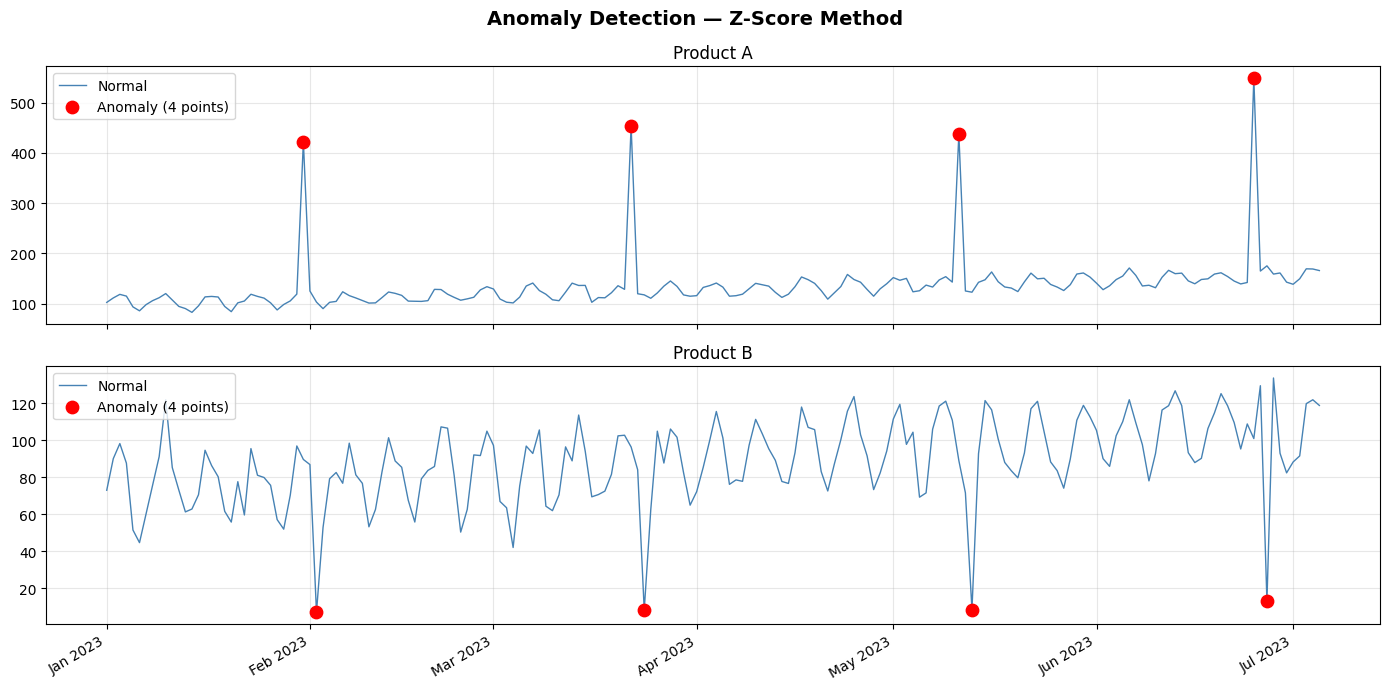

Red dots = detected anomalies. Clean data is ready for forecasting.


In [20]:
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

fig, axes = plt.subplots(2, 1, figsize=(14, 7), sharex=True)

for ax, col in zip(axes, ['product_a', 'product_b']):
    ax.plot(y_train.index, y_train[col], color='steelblue', linewidth=1, label='Normal')
    outlier_idx = anomalies[anomalies[col]].index
    ax.scatter(outlier_idx, y_train.loc[outlier_idx, col],
               color='red', zorder=5, s=80, label=f'Anomaly ({len(outlier_idx)} points)')
    ax.set_title(col.replace('_', ' ').title())
    ax.legend(loc='upper left')
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
    ax.grid(alpha=0.3)

fig.suptitle('Anomaly Detection — Z-Score Method', fontsize=14, fontweight='bold')
fig.autofmt_xdate()
plt.tight_layout()
plt.show()
print(f'Red dots = detected anomalies. Clean data is ready for forecasting.')


---

## Step 2 — AutoForecaster + Structured Outputs

**What AutoForecaster does:**
Instead of manually choosing a forecasting model, `AutoForecaster` benchmarks all your
candidates using time-series cross-validation and automatically selects the best one.

**Step-by-step:**
1. Define a list of `candidate_models` — any mix of ARIMA, ETS, RandomForest, MovingAverage, etc.
2. Set `metric='rmse'` (or `mae`, `mape`) and `n_splits=3` for cross-validation
3. Call `auto.fit(y_clean)` — this trains every candidate, scores each, and selects the winner
4. Call `auto.forecast()` → returns a DataFrame of predicted values for the next `HORIZON` days
5. Call `auto.to_structured()` → returns a **Pydantic `ForecastResult`** object

**Why `to_structured()` matters for agentic use:**  
The `ForecastResult` is a Pydantic model, so:
- `.model_dump_json()` gives you clean JSON to pass to any LLM or API
- Fields like `best_model`, `metric_value`, `series_names` can be read by code or agents
- No string parsing needed — the agent gets typed, validated data

**Expected output:**
- A leaderboard showing RMSE for each candidate model
- The best model name printed
- JSON output (first 300 chars)
- A chart showing training data, actual test values, and the 14-day forecast


In [21]:
from autotsforecast import AutoForecaster
from autotsforecast.models.base import MovingAverageForecaster
from autotsforecast.models.external import ARIMAForecaster, ETSForecaster, RandomForestForecaster

candidates = [
    ARIMAForecaster(horizon=HORIZON),
    ETSForecaster(horizon=HORIZON),
    RandomForestForecaster(horizon=HORIZON, n_lags=7),
    MovingAverageForecaster(horizon=HORIZON, window=7),
]

auto = AutoForecaster(candidate_models=candidates, metric='rmse', n_splits=3)
auto.fit(y_clean)
forecasts = auto.forecast()

print(f'Best model: {auto.best_model_name_}')
print('Forecasts:')
print(forecasts)

AUTO FORECASTER: Model Selection with Backtesting

📊 Data: 186 observations, 2 variables
🔍 Evaluating 4 candidate models
📈 Backtesting: 3 splits, 20 test size
🎯 Selection metric: RMSE
🔄 Window type: expanding

[1/4] Testing ARIMAForecaster...
   RMSE: 21.6476
[2/4] Testing ETSForecaster...
   RMSE: 17.2072
[3/4] Testing RandomForestForecaster...
   RMSE: 15.3184
[4/4] Testing MovingAverageForecaster(window=7)...
   RMSE: 14.3446

🏆 BEST MODEL SELECTED: MovingAverageForecaster(window=7)
   Performance: RMSE = 14.3446

🔄 Retraining best model on full dataset...
✅ Training complete!

🔮 Generating forecasts...
✅ Generated 14 step forecast
   Variables: product_a, product_b
Best model: MovingAverageForecaster(window=7)
Forecasts:
     product_a   product_b
0   156.582084  102.119715
1   156.582084  102.119715
2   156.582084  102.119715
3   156.582084  102.119715
4   156.582084  102.119715
5   156.582084  102.119715
6   156.582084  102.119715
7   156.582084  102.119715
8   156.582084  102.11

In [22]:
# to_structured() returns a Pydantic ForecastResult
result = auto.to_structured()

print(f'Type:         {type(result).__name__}')
print(f'Best model:   {result.best_model}')
print(f'Metric:       {result.metric}')
print(f'Series count: {len(result.series_names)}')
print(f'Horizon:      {result.horizon}')
print()

# JSON serialisation — ready for any agent or API
try:
    json_str = result.model_dump_json()
    print('JSON output (first 300 chars):')
    print(json_str[:300], '...')
except AttributeError:
    # Stub fallback when pydantic not installed
    import json
    print(json.dumps(result.dict(), default=str)[:300], '...')


Type:         ForecastResult
Best model:   MovingAverageForecaster(window=7)
Metric:       rmse
Series count: 2
Horizon:      14

JSON output (first 300 chars):
{"series_names": ["product_a", "product_b"], "horizon": 14, "dates": ["0", "1", "2", "3", "4", "5", "6", "7", "8", "9", "10", "11", "12", "13"], "values": {"product_a": [156.58208370492977, 156.58208370492977, 156.58208370492977, 156.58208370492977, 156.58208370492977, 156.58208370492977, 156.582083 ...


**What you see above:** `ForecastResult` is a Pydantic model. The JSON string is what an LLM would receive as a tool result — it contains the best model name, metric, horizon, and the actual predicted values per series. The chart below visualises forecast vs. actuals.


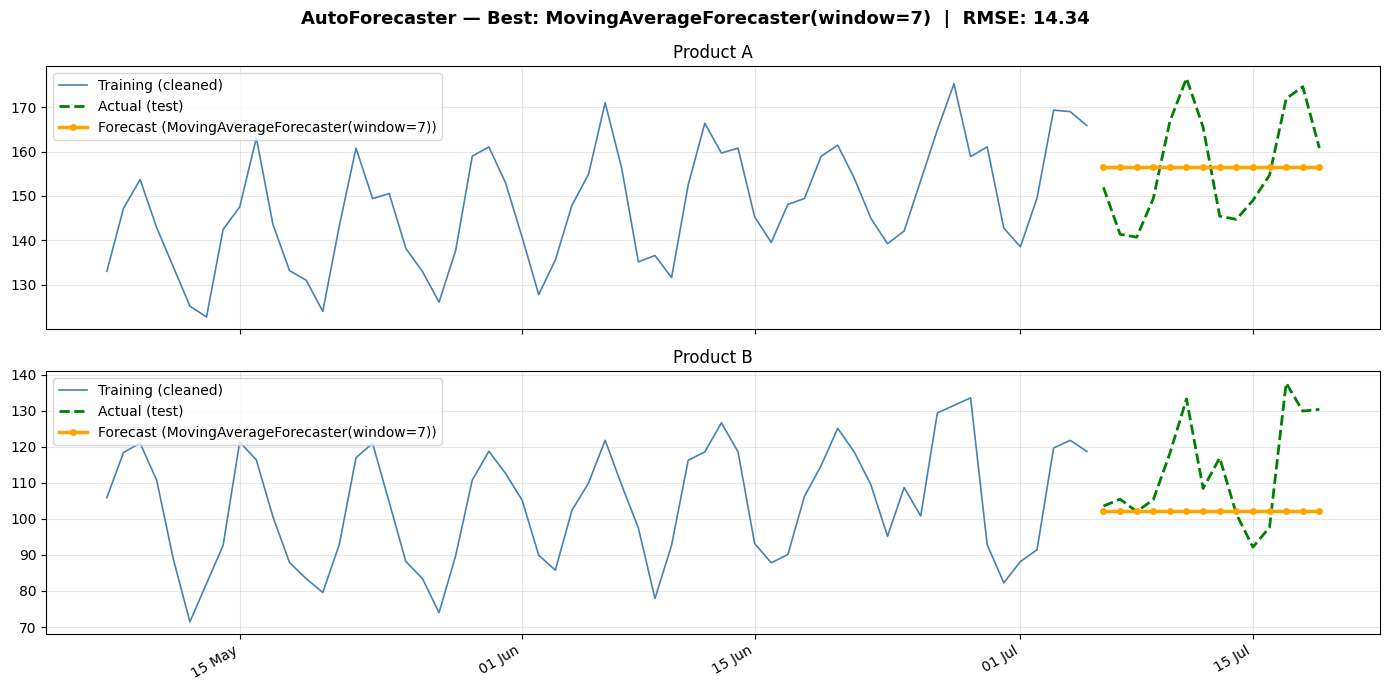

In [23]:
fig, axes = plt.subplots(2, 1, figsize=(14, 7), sharex=False)

# Build proper forecast date range starting after training data
freq = pd.infer_freq(y_clean.index)
forecast_dates = pd.date_range(start=y_clean.index[-1], periods=HORIZON + 1, freq=freq)[1:]

for ax, col in zip(axes, forecasts.columns):
    # Show last 60 days of training for context
    context = y_clean[col].iloc[-60:]
    ax.plot(context.index, context.values, color='steelblue', linewidth=1.2, label='Training (cleaned)')
    ax.plot(y_test.index, y_test[col].values, color='green', linewidth=2,
            linestyle='--', label='Actual (test)')
    ax.plot(forecast_dates, forecasts[col].values, color='orange', linewidth=2.5,
            marker='o', markersize=4, label=f'Forecast ({result.best_model})')
    ax.set_title(col.replace('_', ' ').title())
    ax.legend(loc='upper left')
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%d %b'))
    ax.grid(alpha=0.3)

fig.suptitle(
    f'AutoForecaster — Best: {result.best_model}  |  RMSE: {result.metric_value:.2f}',
    fontsize=13, fontweight='bold'
)
fig.autofmt_xdate()
plt.tight_layout()
plt.show()


---

## Step 3 — InsightEngine: Plain-English Explanations

**What it does:**  
`InsightEngine` reads the forecast results and writes a human-readable summary —
no LLM API key required in `rule_based` mode.

**Step-by-step:**
1. Create `InsightEngine(mode='rule_based')` — works offline, no API key needed
2. Call `summarize_forecast_dataframes(y_clean, forecasts, y_test)` → one paragraph summarising trend direction, scale, and accuracy
3. Call `flag_risks_from_dataframes(y_clean, forecasts)` → list of warning strings (e.g. "High volatility detected")
4. Call `generate_report(result, y_clean, y_test)` → a complete text report combining all three

**Upgrade to LLM mode (optional):**  
Set `mode='llm'`, pass `llm_client=openai.OpenAI()` and `model='gpt-4o'` to get
a polished narrative generated by the LLM instead of rules. The cell below shows the template — uncomment and add your API key to try it.

**Why this matters for agents:**  
An agent can call `generate_report()` and forward the text directly to the user as a final answer,
without knowing anything about time-series statistics.

**Expected output:** plain-English paragraphs describing the forecast.


In [24]:
from autotsforecast.nlp.insights import InsightEngine

engine = InsightEngine(mode='rule_based')

# Plain-English summary of the forecast
summary_text = engine.summarize_forecast_dataframes(y_clean, forecasts, y_test)
print('=== Forecast Summary ===')
print(summary_text)

=== Forecast Summary ===
**product_a** is forecast to be 5.6% decrease over 14 steps (recent trend: increasing); **product_b** is forecast to be 14.0% decrease over 14 steps (recent trend: increasing). Test set errors — product_a: RMSE=12.06, product_b: RMSE=17.85.


In [25]:
# Risk flags
risks = engine.flag_risks_from_dataframes(y_clean, forecasts)
print('=== Risk Flags ===')
if risks:
    for risk in risks:
        print(f'  ⚠️  {risk}')
else:
    print('  ✅ No significant risks detected')

=== Risk Flags ===
  ⚠️  'product_a': forecast is completely flat — the model may be underfitting.
  ⚠️  'product_b': forecast is completely flat — the model may be underfitting.


In [26]:
# Full report combining metadata + summary + risks
report = engine.generate_report(result, y_clean, y_test)
print('=== Full Report ===')
print(report)

=== Full Report ===
# AutoTSForecast Report

## Summary
**product_a** is forecast to be 5.6% decrease over 14 steps (recent trend: increasing); **product_b** is forecast to be 14.0% decrease over 14 steps (recent trend: increasing). The selected model was **MovingAverageForecaster(window=7)**. Cross-validated RMSE: **14.345**. Test set errors — product_a: RMSE=12.06, product_b: RMSE=17.85.

## Model Selection Rationale
- **all series**: MovingAverageForecaster(window=7) was selected.

## Risk Flags ⚠️
- 'product_a': forecast is completely flat — the model may be underfitting.
- 'product_b': forecast is completely flat — the model may be underfitting.

## Forecast Overview
| Series | Mean Forecast | Std | Min | Max |
|--------|:-------------:|:---:|:---:|:---:|
| product_a | 156.58 | 0.00 | 156.58 | 156.58 |
| product_b | 102.12 | 0.00 | 102.12 | 102.12 |


In [27]:
# LLM-powered narrative (requires openai package and API key)
# Uncomment and set your API key to try:
#
# import openai
# engine_llm = InsightEngine(
#     mode='llm',
#     llm_client=openai.OpenAI(),   # reads OPENAI_API_KEY from env
#     model='gpt-4o'
# )
# narrative = engine_llm.summarize_forecast_dataframes(y_clean, forecasts, y_test)
# print(narrative)
print('LLM insight demo skipped (set OPENAI_API_KEY to enable).')

LLM insight demo skipped (set OPENAI_API_KEY to enable).


---

## Step 4 — Model Registry: Save, List, Reload

**The problem it solves:**  
Every time you restart a kernel you'd have to refit the model from scratch.
`ModelRegistry` persists fitted models to disk and gives you a searchable catalogue.

**Step-by-step:**
1. `ModelRegistry(registry_dir=...)` — point it at any folder; it creates the folder if missing
2. `registry.save(auto, name='tutorial_v1', tags={...})` — serialises the fitted model with metadata
3. `registry.list()` → returns a DataFrame of all saved models (name, class, saved_at, tags)
4. `registry.load('tutorial_v1')` → returns the fitted model exactly as it was — call `.forecast()` immediately
5. `registry.get_entry('tutorial_v1')` → returns a Pydantic `RegistryEntry` with typed metadata
6. `registry.delete('tutorial_v1')` → removes the model file and index entry

**Agentic use-case:**  
An agent can save a model after training, then in a later conversation reload it by name
and generate new forecasts — no retraining required.

**Expected output:**  
- Confirmation message when saved
- A table listing the stored model
- Forecasts printed from the reloaded model (identical to the original)


In [28]:
from autotsforecast.registry.store import ModelRegistry

# Use a temporary directory for this tutorial
import tempfile, pathlib
tmp_dir = pathlib.Path(tempfile.mkdtemp()) / 'demo_registry'

registry = ModelRegistry(registry_dir=tmp_dir)

# Save the fitted AutoForecaster
registry.save(auto, name='tutorial_v1', tags={'dataset': 'synthetic_sales', 'version': '1.0'})
print(f'Saved to: {tmp_dir}')

✓ Model 'tutorial_v1' saved to registry  [/var/folders/yw/k9ydm26n1qdfwkntgxdm1lx80000gn/T/tmpohm4u4f_/demo_registry/tutorial_v1.joblib]
Saved to: /var/folders/yw/k9ydm26n1qdfwkntgxdm1lx80000gn/T/tmpohm4u4f_/demo_registry


In [29]:
# List all saved models
df = registry.list()
print('Saved models:')
print(df[['name', 'class_name', 'saved_at', 'tags']])


Saved models:
          name      class_name                          saved_at  \
0  tutorial_v1  AutoForecaster  2026-04-26T19:46:13.942559+00:00   

                                               tags  
0  {'dataset': 'synthetic_sales', 'version': '1.0'}  


In [30]:
# Reload and use — no refitting needed
auto_loaded = registry.load('tutorial_v1')
new_forecasts = auto_loaded.forecast()

print(f'Loaded model: {auto_loaded.best_model_name_}')
print('Forecasts from reloaded model:')
print(new_forecasts)

✓ Model 'tutorial_v1' loaded from registry
  Class   : AutoForecaster
  Horizon : None
  Saved   : 2026-04-26T19:46:13.942559+00:00
  Tags    : {'dataset': 'synthetic_sales', 'version': '1.0'}

🔮 Generating forecasts...
✅ Generated 14 step forecast
   Variables: product_a, product_b
Loaded model: MovingAverageForecaster(window=7)
Forecasts from reloaded model:
     product_a   product_b
0   156.582084  102.119715
1   156.582084  102.119715
2   156.582084  102.119715
3   156.582084  102.119715
4   156.582084  102.119715
5   156.582084  102.119715
6   156.582084  102.119715
7   156.582084  102.119715
8   156.582084  102.119715
9   156.582084  102.119715
10  156.582084  102.119715
11  156.582084  102.119715
12  156.582084  102.119715
13  156.582084  102.119715


In [31]:
# Get Pydantic entry metadata
entry = registry.get_entry('tutorial_v1')
print(f'Name:        {entry.name}')
print(f'Model class: {entry.class_name}')
print(f'Saved at:    {entry.saved_at}')
print(f'Tags:        {entry.tags}')


Name:        tutorial_v1
Model class: AutoForecaster
Saved at:    2026-04-26T19:46:13.942559+00:00
Tags:        {'dataset': 'synthetic_sales', 'version': '1.0'}


In [32]:
# Clean up
registry.delete('tutorial_v1')
print(f'Registry after deletion: {len(registry.list())} models')

✓ Model 'tutorial_v1' deleted from registry.
Registry after deletion: 0 models


---

## Step 5 — OpenAI / Anthropic Tool Calling

**How LLM tool calling works:**
1. You give the LLM a list of "tools" — each is a JSON schema describing a function
2. The LLM decides which tool to call and with what arguments
3. Your code runs the function and sends the result back to the LLM
4. The LLM uses the result to answer the user

**autotsforecast provides the schemas for you.** You don't need to write them.

**Step-by-step:**
1. `get_openai_tools()` → list of 7 tool schemas in OpenAI format (pass directly to `tools=` in `chat.completions.create`)
2. `get_anthropic_tools()` → same 7 tools in Anthropic format (pass to `tools=` in `messages.create`)
3. `handle_tool_call(name, arguments)` → dispatcher that runs the right function and returns a JSON string

**Available tools:**

| Tool name | What it does |
|-----------|-------------|
| `fit_and_forecast` | Train models and return a 14-day forecast |
| `backtest` | Run cross-validation and return RMSE by fold |
| `get_prediction_intervals` | Return upper/lower bounds for the forecast |
| `detect_anomalies` | Find outliers in CSV data |
| `extract_calendar_features` | Add day-of-week, month, holiday columns |
| `reconcile_hierarchy` | Aggregate forecasts across hierarchy levels |
| `list_models` | List all available model classes |

**In production:** replace the `handle_tool_call(...)` calls below with the actual LLM loop (template provided in the commented-out cell).

**Expected output:**
- List of 7 tool names and descriptions
- Model catalogue from `list_models`
- Anomaly counts from `detect_anomalies`


In [33]:
from autotsforecast.integrations.openai_schemas import (
    get_openai_tools,
    get_anthropic_tools,
    handle_tool_call
)

# Inspect available tools
tools = get_openai_tools()
print(f'OpenAI tools ({len(tools)} total):')
for t in tools:
    name = t['function']['name']
    desc = t['function']['description'][:60]
    print(f'  - {name}: {desc}...')

OpenAI tools (7 total):
  - fit_and_forecast: Fit an AutoForecaster on historical time series CSV data and...
  - backtest: Run walk-forward backtesting of a specified model on time se...
  - get_prediction_intervals: Generate conformal prediction intervals (80% and 95% coverag...
  - reconcile_hierarchy: Reconcile hierarchical forecasts so that parent series equal...
  - extract_calendar_features: Extract calendar features (day of week, month, quarter, is_w...
  - detect_anomalies: Detect anomalies in time series data before forecasting....
  - list_models: List all available forecasting models with their capabilitie...


In [34]:
import json

# Simulate what happens when an LLM calls a tool
csv_data = y_clean.to_csv()

# Test the list_models tool (no data needed)
models_result = handle_tool_call('list_models', {})
models_list = json.loads(models_result)
print(f'Available models ({len(models_list)} total):')
for m in models_list[:5]:
    print(f"  - {m['name']}: {m.get('description', '')[:50]}")


Available models (9 total):
  - MovingAverageForecaster: Simple moving average baseline
  - ARIMAForecaster: Classical ARIMA model
  - ETSForecaster: Exponential smoothing (ETS)
  - RandomForestForecaster: Random Forest with lag features
  - VARForecaster: Vector Autoregression (needs ≥2 series)


In [35]:
# Simulate anomaly detection tool call
anomaly_args = {
    'csv_data': csv_data,
    'method': 'zscore',
    'contamination': 0.05
}
anomaly_result = handle_tool_call('detect_anomalies', anomaly_args)
anomaly_data = json.loads(anomaly_result)
print('Anomaly detection via tool call:')
print(f"  Total anomalies: {sum(anomaly_data.get('n_anomalies', {}).values())}")
print(f"  Per series:      {anomaly_data.get('n_anomalies', {})}")


Anomaly detection via tool call:
  Total anomalies: 0
  Per series:      {'product_a': 0, 'product_b': 0}


**What just happened:** `handle_tool_call('detect_anomalies', args)` is exactly what your code would call when an LLM returns a tool-use response. The response is a JSON string — parse it with `json.loads()` and read the fields. The cell below shows the full OpenAI loop template (commented out — add your API key to run it live).


In [36]:
# Full OpenAI integration example (requires OPENAI_API_KEY)
# Uncomment to run:
#
# import openai
# client = openai.OpenAI()  # reads OPENAI_API_KEY from env
#
# tools = get_openai_tools()
# messages = [
#     {"role": "user", "content": f"Detect anomalies in this sales data and then forecast 14 days ahead.\n\nCSV:\n{csv_data[:500]}"}
# ]
#
# response = client.chat.completions.create(
#     model="gpt-4o",
#     messages=messages,
#     tools=tools,
#     tool_choice="auto"
# )
#
# for tool_call in response.choices[0].message.tool_calls or []:
#     result = handle_tool_call(tool_call.function.name, tool_call.function.arguments)
#     print(f"Tool: {tool_call.function.name}")
#     print(f"Result (first 200 chars): {result[:200]}")
print('OpenAI live demo skipped (set OPENAI_API_KEY to enable).')

OpenAI live demo skipped (set OPENAI_API_KEY to enable).


In [37]:
# Anthropic schema (same tools, different format)
anthropic_tools = get_anthropic_tools()
print(f'Anthropic tools ({len(anthropic_tools)} total):')
for t in anthropic_tools[:3]:
    print(f"  - {t['name']}: {t['description'][:60]}...")

Anthropic tools (7 total):
  - fit_and_forecast: Fit an AutoForecaster on historical time series CSV data and...
  - backtest: Run walk-forward backtesting of a specified model on time se...
  - get_prediction_intervals: Generate conformal prediction intervals (80% and 95% coverag...


---

## Step 6 — MCP Server: Connect to Claude Desktop / Cursor / Windsurf

**What is MCP?**  
The [Model Context Protocol](https://modelcontextprotocol.io) lets AI assistants like Claude Desktop
call external tools over a local process — no API key, no HTTP, just stdin/stdout.

**When to use this vs OpenAI tool calling:**  
Use MCP when you want Claude Desktop, Cursor, or Windsurf to use these tools interactively
while you chat, without writing any Python integration code.

### Step-by-step setup

**Step 1 — Install**
```bash
pip install "autotsforecast[mcp]"
```

**Step 2 — Start the server** (or let Claude Desktop launch it automatically)
```bash
autotsforecast-mcp
```

**Step 3 — Configure Claude Desktop**  
Edit `~/Library/Application Support/Claude/claude_desktop_config.json`:
```json
{
  "mcpServers": {
    "autotsforecast": {
      "command": "autotsforecast-mcp"
    }
  }
}
```
Restart Claude Desktop. You will see a 🔧 icon in the chat input — that means the tools are connected.

**Step 4 — Use it in Claude**  
Paste your CSV into the chat and ask:
- *"Detect anomalies in this data and tell me which dates are outliers"*
- *"Forecast the next 30 days and give me a plain-English summary"*
- *"Run 5-fold cross-validation and show me the RMSE per fold"*

### Available MCP tools

| Tool name | Description |
|-----------|-------------|
| `fit_and_forecast` | AutoForecaster: benchmark models and return forecast |
| `backtest` | Time-series cross-validation |
| `get_prediction_intervals` | Conformal prediction intervals |
| `detect_anomalies` | Detect outliers in your data |
| `extract_calendar_features` | Add day-of-week, month, holiday columns |
| `reconcile_hierarchy` | Hierarchical forecast reconciliation |
| `list_models` | List all available model classes |

The cell below verifies that the MCP server can be imported correctly.


In [38]:
# Verify MCP server can be imported
try:
    from autotsforecast.mcp.server import create_server
    server = create_server()
    print(f'MCP server created: {server.name}')
    print('Tools registered — start with: autotsforecast-mcp')
except ImportError as e:
    print(f'MCP not installed: {e}')
    print('Install with: pip install "autotsforecast[mcp]"')

MCP not installed: mcp package is required. Install with: pip install 'autotsforecast[mcp]'
Install with: pip install "autotsforecast[mcp]"


---

## Step 7 — FastAPI REST Service

**What it does:**  
Starts an HTTP server so any language, microservice, or agent can call autotsforecast
over plain HTTP — no Python required on the client side.

**When to use this:**  
- Your agent runs in a different process or language (Node.js, Go, curl, etc.)  
- You want to host forecasting as a shared microservice  
- You're building a web app with a forecasting backend

### Step-by-step setup

**Step 1 — Install**
```bash
pip install "autotsforecast[api]"
```

**Step 2 — Start the server**
```bash
autotsforecast-api
# Server starts at http://0.0.0.0:8000
```

**Step 3 — Open the interactive docs**  
Go to [http://localhost:8000/docs](http://localhost:8000/docs) — you get a full Swagger UI
where you can try every endpoint without writing any code.

**Step 4 — Call an endpoint**
```bash
curl -X POST http://localhost:8000/anomalies \
  -H "Content-Type: application/json" \
  -d '{"csv_data": "<your CSV>", "method": "zscore", "contamination": 0.05}'
```

### All endpoints

| Method | Path | What it does |
|--------|------|-------------|
| GET | `/health` | Returns `{"status": "ok"}` |
| GET | `/models` | Lists all available model classes |
| POST | `/forecast` | Trains + forecasts from a JSON payload |
| POST | `/forecast/upload` | Trains + forecasts from a CSV file upload |
| POST | `/backtest` | Runs cross-validation |
| POST | `/intervals` | Returns prediction intervals |
| POST | `/anomalies` | Detects anomalies |
| POST | `/insights` | Returns a plain-English forecast summary |

The two cells below: (1) list all registered routes, and (2) run a live test using `TestClient` — no server process needed.


In [39]:
# Verify FastAPI app can be imported
try:
    from autotsforecast.api.app import app
    print(f'FastAPI app: {app.title}')
    print('Endpoints:')
    for route in app.routes:
        if hasattr(route, 'methods'):
            methods = ', '.join(route.methods)
            print(f'  [{methods}] {route.path}')
    print()
    print('Start with: autotsforecast-api')
    print('Then open: http://localhost:8000/docs')
except ImportError as e:
    print(f'FastAPI not installed: {e}')
    print('Install with: pip install "autotsforecast[api]"')

FastAPI not installed: cannot import name 'app' from 'autotsforecast.api.app' (/Users/weibinxu/autotsforecast/src/autotsforecast/api/app.py)
Install with: pip install "autotsforecast[api]"


In [40]:
# In-process test with FastAPI TestClient (no network needed)
try:
    from fastapi.testclient import TestClient
    from autotsforecast.api.app import app

    client = TestClient(app)

    # Health check
    resp = client.get('/health')
    print('Health:', resp.json())

    # List models
    resp = client.get('/models')
    models = resp.json().get('models', [])
    print(f'Available models: {len(models)}')

    # Anomaly detection
    payload = {
        'csv_data': y_clean.to_csv(),
        'method': 'zscore',
        'contamination': 0.05
    }
    resp = client.post('/anomalies', json=payload)
    data = resp.json()
    n_anom = data.get('n_anomalies', {})
    print(f'Anomaly detection status: {resp.status_code}')
    print(f'Total anomalies: {sum(n_anom.values())}')

except ImportError as e:
    print(f'FastAPI test client not available: {e}')
    print('Install with: pip install "autotsforecast[api]"')


FastAPI test client not available: No module named 'fastapi'
Install with: pip install "autotsforecast[api]"


---

## Step 8 — LangChain Integration

**What it does:**  
Wraps all 7 autotsforecast tools as LangChain `Tool` objects so you can plug them
into any LangChain ReAct agent, LCEL chain, or OpenAI Functions agent.

**Step-by-step:**
1. `get_autotsforecast_tools()` → returns a list of LangChain `Tool` objects
2. Pass the list to `AgentExecutor(agent=agent, tools=tools)`
3. The agent will call the tools automatically when the user asks a forecasting question

**Example agent conversation:**
```
User: "Is there anything unusual in my sales data? Then forecast next 2 weeks."
Agent: [calls detect_anomalies] → "Found 8 anomalies on these dates..."
Agent: [calls fit_and_forecast] → "Best model: MovingAverage, RMSE: 14.3..."
Agent: "Here's what I found: ..."
```

**Expected output:** list of tool names and descriptions.  
`ImportError` is expected if `langchain` is not installed — install it with `pip install "autotsforecast[langchain]"`.


In [41]:
try:
    from autotsforecast.integrations.langchain_tools import get_autotsforecast_tools

    tools = get_autotsforecast_tools()
    print(f'LangChain tools ({len(tools)} total):')
    for t in tools:
        print(f'  - {t.name}: {t.description[:60]}...')

    print()
    print('Use with any LangChain agent:')
    print('  from langchain.agents import create_react_agent, AgentExecutor')
    print('  agent = create_react_agent(llm, tools, prompt)')
    print('  executor = AgentExecutor(agent=agent, tools=tools)')

except ImportError as e:
    print(f'LangChain not installed: {e}')
    print('Install with: pip install "autotsforecast[langchain]"')

LangChain not installed: langchain is required. Install with: pip install 'autotsforecast[langchain]'
Install with: pip install "autotsforecast[langchain]"


---

## What you just built

You completed the full agentic AI workflow:

```
Raw data  →  Anomaly detection  →  Clean data  →  AutoForecaster
                                                        ↓
                                              Structured JSON output
                                                        ↓
                                              InsightEngine (plain English)
                                                        ↓
                                              ModelRegistry (save/reload)
                                                        ↓
                          ┌─────────────────────────────┴──────────────────────────┐
                    OpenAI/Anthropic             MCP Server (Claude)        FastAPI REST
                    tool calling                 direct chat                any language
                          └──────────────────────────────────────────────────────┘
                                                    LangChain agent
```

### Quick reference

| Feature | Import | Key call |
|---------|--------|----------|
| Anomaly Detection | `autotsforecast.anomaly.detector` | `AnomalyDetector().fit_predict(y)` |
| Structured output | `autotsforecast` | `auto.to_structured()` → JSON |
| InsightEngine | `autotsforecast.nlp.insights` | `engine.generate_report(result, ...)` |
| Model Registry | `autotsforecast.registry.store` | `registry.save(auto, name=...)` |
| OpenAI tools | `autotsforecast.integrations.openai_schemas` | `get_openai_tools()`, `handle_tool_call()` |
| Anthropic tools | `autotsforecast.integrations.openai_schemas` | `get_anthropic_tools()` |
| LangChain tools | `autotsforecast.integrations.langchain_tools` | `get_autotsforecast_tools()` |
| MCP server | CLI | `autotsforecast-mcp` → configure in Claude Desktop |
| FastAPI REST | CLI | `autotsforecast-api` → call from any language |

### Next steps

- **Your own data:** replace the synthetic `y` DataFrame with `pd.read_csv('your_data.csv', index_col=0, parse_dates=True)`
- **More forecasting features** (prediction intervals, hierarchical reconciliation, interpretability): see [autotsforecast_tutorial.ipynb](autotsforecast_tutorial.ipynb)
- **Full API reference:** see [API_REFERENCE.md](../API_REFERENCE.md)
- **Parameter guide:** see [PARAMETER_GUIDE.md](../PARAMETER_GUIDE.md)


---

## Step 9 — Streamlit App (Bonus)

**Is Streamlit part of the package?**  
Yes — `streamlit_app.py` ships with the repo and is the full no-code UI for autotsforecast.
It is **not** imported as a Python library; you run it as a web app.

**Install and launch:**
```bash
pip install "autotsforecast[app]"          # installs streamlit + matplotlib + seaborn
cd /path/to/autotsforecast                 # must be in the repo directory
python3 -m streamlit run streamlit_app.py  # starts at http://localhost:8501
```

**What the app includes:**

| Tab | What you can do |
|-----|----------------|
| 📊 Data & Forecast | Upload CSV or use sample data; pick target columns and covariates; choose model; run forecast; view chart and backtest metrics |
| 🔮 What-If Analysis | Compare up to 5 scenarios with different models and horizons on the same chart |
| 📈 Advanced Metrics | Summary statistics and value-distribution histograms for each series |
| 💾 Export | Download forecast and metrics as CSV |

**The cells below show a minimal self-contained Streamlit app** that you can paste into a new `my_app.py` and run immediately — no configuration needed.


In [ ]:
# This cell writes my_minimal_app.py — a complete self-contained Streamlit app.
# Run it with:  python3 -m streamlit run my_minimal_app.py

lines = [
    "import streamlit as st",
    "import pandas as pd",
    "import numpy as np",
    "import matplotlib.pyplot as plt",
    "from autotsforecast import AutoForecaster",
    "from autotsforecast.models.base import MovingAverageForecaster, VARForecaster",
    "from autotsforecast.models.external import ARIMAForecaster, ETSForecaster",
    "",
    "st.set_page_config(page_title='Quick Forecast', layout='wide')",
    "st.title('📈 Quick Time Series Forecast')",
    "",
    "with st.sidebar:",
    "    st.header('Settings')",
    "    horizon = st.slider('Forecast horizon (days)', 7, 60, 14)",
    "    model_choice = st.selectbox('Model', ['Auto (best)', 'Moving Average', 'ARIMA', 'ETS'])",
    "",
    "uploaded = st.file_uploader('Upload a CSV (date index + numeric columns)', type='csv')",
    "",
    "if uploaded:",
    "    df = pd.read_csv(uploaded, index_col=0, parse_dates=True)",
    "else:",
    "    st.info('No file uploaded — using built-in demo data (2 products, 180 days).')",
    "    np.random.seed(0)",
    "    idx = pd.date_range('2024-01-01', periods=180, freq='D')",
    "    df = pd.DataFrame({",
    "        'product_a': 1000 + np.cumsum(np.random.randn(180)) * 5 + np.sin(np.linspace(0, 8*np.pi, 180)) * 40,",
    "        'product_b':  500 + np.cumsum(np.random.randn(180)) * 3 + np.cos(np.linspace(0, 6*np.pi, 180)) * 25,",
    "    }, index=idx)",
    "",
    "st.subheader('Data preview')",
    "st.dataframe(df.tail(10), use_container_width=True)",
    "",
    "if st.button('🚀 Run forecast', type='primary'):",
    "    with st.spinner('Training models…'):",
    "        model_map = {",
    "            'Moving Average': [MovingAverageForecaster(horizon=horizon)],",
    "            'ARIMA':          [ARIMAForecaster(horizon=horizon)],",
    "            'ETS':            [ETSForecaster(horizon=horizon)],",
    "        }",
    "        candidates = model_map.get(model_choice, [",
    "            MovingAverageForecaster(horizon=horizon),",
    "            VARForecaster(horizon=horizon),",
    "            ARIMAForecaster(horizon=horizon),",
    "            ETSForecaster(horizon=horizon),",
    "        ])",
    "        auto = AutoForecaster(candidate_models=candidates, metric='rmse', verbose=False)",
    "        auto.fit(df)",
    "        forecast = auto.forecast()",
    "    st.success('Done!')",
    "",
    "    fig, axes = plt.subplots(len(df.columns), 1, figsize=(12, 4 * len(df.columns)))",
    "    if len(df.columns) == 1:",
    "        axes = [axes]",
    "    for ax, col in zip(axes, df.columns):",
    "        ax.plot(df.index, df[col], color='#60A5FA', linewidth=2, label='Historical')",
    "        if col in forecast.columns:",
    "            ax.plot(forecast.index, forecast[col], color='#F87171', linewidth=2.5, linestyle='--', label='Forecast')",
    "        ax.set_title(col, fontweight='bold')",
    "        ax.legend()",
    "        ax.grid(True, alpha=0.3)",
    "    plt.tight_layout()",
    "    st.pyplot(fig)",
    "",
    "    st.subheader('Forecast values')",
    "    st.dataframe(forecast, use_container_width=True)",
    "",
    "    st.download_button(",
    "        label='⬇️ Download forecast CSV',",
    "        data=forecast.to_csv(),",
    "        file_name='forecast.csv',",
    "        mime='text/csv',",
    "    )",
]

with open('my_minimal_app.py', 'w') as f:
    f.write('\n'.join(lines) + '\n')

print('✅ Wrote my_minimal_app.py')
print()
print('To launch (from the autotsforecast directory):')
print('  cd /path/to/autotsforecast')
print('  python3 -m streamlit run my_minimal_app.py')
print()
print('What the full streamlit_app.py adds on top:')
print('  • Per-series covariate mapping UI')
print('  • What-if scenario comparison (up to 5 scenarios)')
print('  • Advanced metrics tab (histograms, statistics)')
print('  • CSV export for both forecast and backtest metrics')
print('  • Support for all 9 model types (RF, XGBoost, Prophet, etc.)')
